In [113]:
import numpy as np

In [115]:
chiral_mat = np.load('C:\\Users\\robwa\\liif-main\\datasets\\Schwinger\\test\\rainbow\\N8w3_high.npy')
chiral_mat = np.reshape(chiral_mat[0], (192, 192))

In [117]:
one_array = np.ones((192, 192))
g = 3
mu_list = np.linspace(0, (g*1.4), 192)
T_list = np.linspace(0.1, (g*2.5), 192)

0.06371523890422671 0.5872167622163597


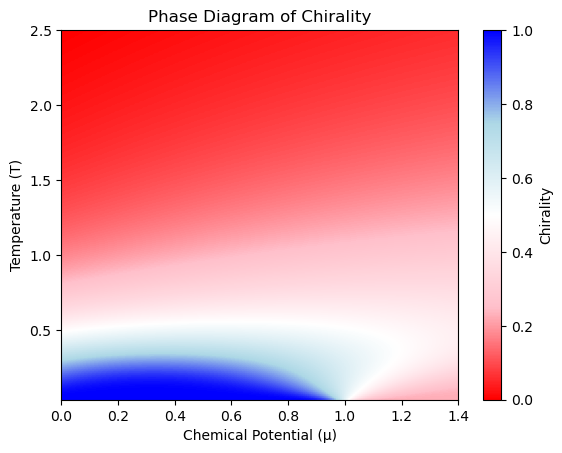

In [119]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as mcolors

# 假设mu_list和T_list已经定义，并且与chiral_mat的对应轴长度相同

# 将chiral_mat转换为numpy数组以便于处理
chiral_mat_antisigma = -np.log(np.divide(one_array, chiral_mat) - one_array)
chiral_mat_antisigma = np.transpose(np.abs(np.array(chiral_mat_antisigma)))

min_val = np.min(chiral_mat_antisigma)
max_val = np.max(chiral_mat_antisigma)
print(min_val, max_val)

chiral_mat_antisigma = (chiral_mat_antisigma - min_val)/(max_val - min_val)

transition_sites = []

for i in range(192):
    for j in range(192):
        if chiral_mat_antisigma[i][j] > 0.4 and chiral_mat_antisigma[i][j] < 0.6:
            transition_sites.append([i, j])

# 创建自定义颜色图，0.5前后颜色不同且渐变
colors = ['red', 'pink', 'white', 'lightblue', 'blue']
cmap = mcolors.LinearSegmentedColormap.from_list('custom_cmap', colors)


# 创建图形和轴
fig, ax = plt.subplots()

# 创建热图
cax = ax.imshow(chiral_mat_antisigma, aspect='auto', cmap=cmap, origin='lower', extent=[min(mu_list/g), max(mu_list/g), min(T_list/g), max(T_list/g)])

# 添加颜色条
cbar = fig.colorbar(cax)
cbar.set_label('Chirality')



# 设置轴标签
ax.set_xlabel('Chemical Potential (μ)')
ax.set_ylabel('Temperature (T)')

# 添加0.5等值线
#contour = ax.contour(chiral_mat, levels=[0.5], colors='black', origin='lower', extent=[min(mu_list/g), max(mu_list/g), min(T_list/g), max(T_list/g)])
#ax.clabel(contour, inline=1, fontsize=10)

# 设置标题
ax.set_title('Phase Diagram of Chirality')

# 显示图形
plt.show()

In [121]:
one_array_low = np.ones((48, 48))
mu_list_low = np.linspace(0, (g*1.4), 48)
T_list_low = np.linspace(0.1, (g*2.5), 48)

In [123]:
chiral_mat_low = np.load('C:\\Users\\robwa\\liif-main\\datasets\\Schwinger\\test\\rainbow\\N8w3.npy')
chiral_mat_low = np.reshape(chiral_mat_low[0], (48, 48))

0.5159234231544285 0.6427262871912114


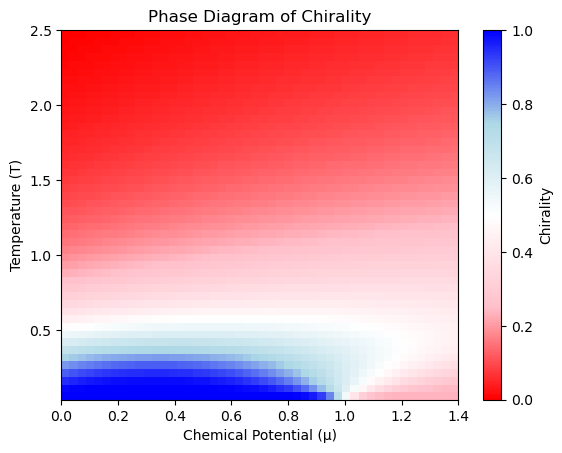

In [125]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as mcolors

# 假设mu_list和T_list已经定义，并且与chiral_mat的对应轴长度相同

# 将chiral_mat转换为numpy数组以便于处理
chiral_mat_low_antisigma = np.transpose(np.abs(np.array(chiral_mat_low)))

min_val = np.min(chiral_mat_low_antisigma)
max_val = np.max(chiral_mat_low_antisigma)
print(min_val, max_val)

chiral_mat_low_antisigma = (chiral_mat_low_antisigma - min_val)/(max_val - min_val)



# 创建自定义颜色图，0.5前后颜色不同且渐变
colors = ['red', 'pink', 'white', 'lightblue', 'blue']
cmap = mcolors.LinearSegmentedColormap.from_list('custom_cmap', colors)


# 创建图形和轴
fig, ax = plt.subplots()

# 创建热图
cax = ax.imshow(chiral_mat_low_antisigma, aspect='auto', cmap=cmap, origin='lower', extent=[min(mu_list_low/g), max(mu_list_low/g), min(T_list_low/g), max(T_list_low/g)])

# 添加颜色条
cbar = fig.colorbar(cax)
cbar.set_label('Chirality')



# 设置轴标签
ax.set_xlabel('Chemical Potential (μ)')
ax.set_ylabel('Temperature (T)')

# 添加0.5等值线
#contour = ax.contour(chiral_mat, levels=[0.5], colors='black', origin='lower', extent=[min(mu_list/g), max(mu_list/g), min(T_list/g), max(T_list/g)])
#ax.clabel(contour, inline=1, fontsize=10)

# 设置标题
ax.set_title('Phase Diagram of Chirality')

# 显示图形
plt.show()

In [127]:
pred_diff = np.load('C:\\Users\\robwa\\liif-main\\datasets\\Schwinger\\test\\rainbow\\N8w3_high_diff.npy')

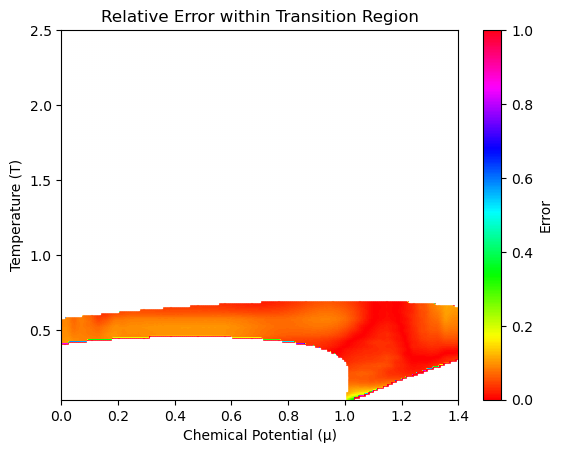

In [129]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as mcolors

# 假设mu_list和T_list已经定义，并且与chiral_mat的对应轴长度相同

pred_diff = np.transpose(np.abs(np.array(pred_diff)))


for i in range(192):
    for j in range(192):
        if [i, j] not in transition_sites:
            pred_diff[i][j] = 10

white_spots = []
for i in range(192):
    for j in range(192):
        if pred_diff[i][j] == 10:
            white_spots.append([i, j])

# 创建自定义颜色图，0.5前后颜色不同且渐变
#colors = ['red', 'pink', 'white', 'lightblue', 'blue']
#cmap = mcolors.LinearSegmentedColormap.from_list('custom_cmap', colors)

norm = mcolors.Normalize(vmin=0, vmax=1)

# 创建图形和轴
fig, ax = plt.subplots()

# 创建热图

cax = ax.imshow(pred_diff, aspect='auto', cmap='hsv', origin='lower', extent=[min(mu_list/g), max(mu_list/g), min(T_list/g), max(T_list/g)], norm = norm)

# 添加颜色条
cbar = fig.colorbar(cax)
cbar.set_label('Error')

for coordinate in white_spots:
    x = coordinate[1]
    y = coordinate[0]
    x_value = x * (1.4/(192 - 1))
    y_value = (0.1/3) + y * ((2.5 - 0.1/3)/(192 - 1))
    plt.plot(x_value, y_value, 'w', marker = 's', markersize = 1.5)

# 设置轴标签
ax.set_xlabel('Chemical Potential (μ)')
ax.set_ylabel('Temperature (T)')

# 添加0.5等值线
#contour = ax.contour(chiral_mat, levels=[0.5], colors='black', origin='lower', extent=[min(mu_list/g), max(mu_list/g), min(T_list/g), max(T_list/g)])
#ax.clabel(contour, inline=1, fontsize=10)

# 设置标题
ax.set_title('Relative Error within Transition Region')

# 显示图形
plt.show()

In [131]:
interpo_diff = np.load('C:\\Users\\robwa\\liif-main\\datasets\\Schwinger\\test\\rainbow\\N8w3_high_interpo.npy')

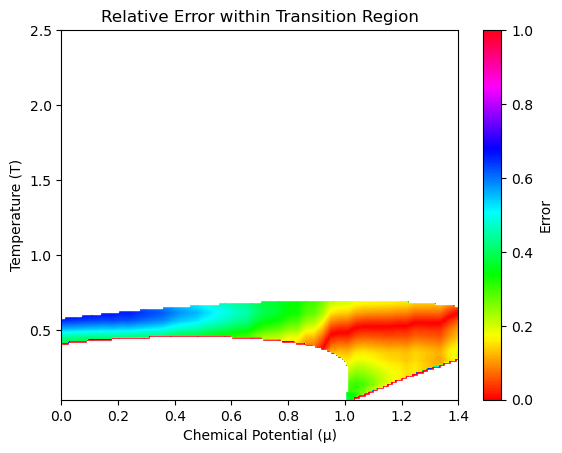

In [133]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as mcolors

# 假设mu_list和T_list已经定义，并且与chiral_mat的对应轴长度相同

interpo_diff = np.transpose(np.abs(np.array(interpo_diff)))


for i in range(192):
    for j in range(192):
        if [i, j] not in transition_sites:
            interpo_diff[i][j] = 10

white_spots = []
for i in range(192):
    for j in range(192):
        if interpo_diff[i][j] == 10:
            white_spots.append([i, j])

# 创建自定义颜色图，0.5前后颜色不同且渐变
#colors = ['red', 'pink', 'white', 'lightblue', 'blue']
#cmap = mcolors.LinearSegmentedColormap.from_list('custom_cmap', colors)

norm = mcolors.Normalize(vmin=0, vmax=1)

# 创建图形和轴
fig, ax = plt.subplots()

# 创建热图

cax = ax.imshow(interpo_diff, aspect='auto', cmap='hsv', origin='lower', extent=[min(mu_list/g), max(mu_list/g), min(T_list/g), max(T_list/g)], norm = norm)

# 添加颜色条
cbar = fig.colorbar(cax)
cbar.set_label('Error')

for coordinate in white_spots:
    x = coordinate[1]
    y = coordinate[0]
    x_value = x * (1.4/(192 - 1))
    y_value = (0.1/3) + y * ((2.5 - 0.1/3)/(192 - 1))
    plt.plot(x_value, y_value, 'w', marker = 's', markersize = 1.5)

# 设置轴标签
ax.set_xlabel('Chemical Potential (μ)')
ax.set_ylabel('Temperature (T)')

# 添加0.5等值线
#contour = ax.contour(chiral_mat, levels=[0.5], colors='black', origin='lower', extent=[min(mu_list/g), max(mu_list/g), min(T_list/g), max(T_list/g)])
#ax.clabel(contour, inline=1, fontsize=10)

# 设置标题
ax.set_title('Relative Error within Transition Region')

# 显示图形
plt.show()

In [135]:
chiral_mat_N12 = np.load('C:\\Users\\robwa\\liif-main\\datasets\\Schwinger\\test\\N12\\N12w3_true_high_resolution.npy')
chiral_mat_N12 = np.reshape(chiral_mat_N12[0], (192, 192))

In [137]:
mu_list = np.linspace(0, (g*1.4), 192)
T_list = np.linspace(0.1, (g*2.5), 192)

0.05676254661461738 0.623958940313742


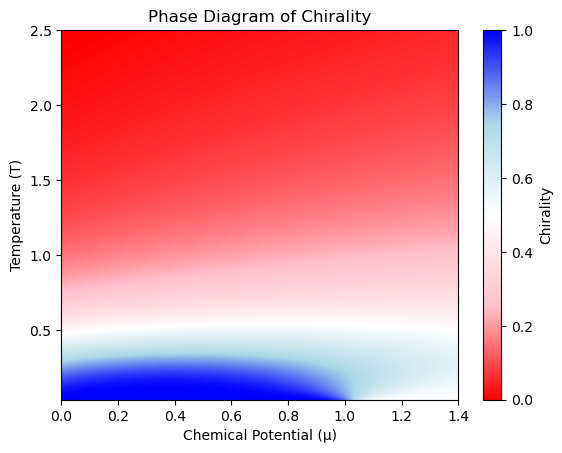

In [139]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as mcolors

# 假设mu_list和T_list已经定义，并且与chiral_mat的对应轴长度相同

# 将chiral_mat转换为numpy数组以便于处理
chiral_mat_N12_antisigma = -np.log(np.divide(one_array, chiral_mat_N12) - one_array)
chiral_mat_N12_antisigma = np.transpose(np.abs(np.array(chiral_mat_N12_antisigma)))

min_val = np.min(chiral_mat_N12_antisigma)
max_val = np.max(chiral_mat_N12_antisigma)
print(min_val, max_val)

chiral_mat_N12_antisigma = (chiral_mat_N12_antisigma - min_val)/(max_val - min_val)

transition_sites_12 = []

for i in range(192):
    for j in range(192):
        if chiral_mat_N12_antisigma[i][j] > 0.4 and chiral_mat_N12_antisigma[i][j] < 0.6:
            transition_sites_12.append([i, j])

# 创建自定义颜色图，0.5前后颜色不同且渐变
colors = ['red', 'pink', 'white', 'lightblue', 'blue']
cmap = mcolors.LinearSegmentedColormap.from_list('custom_cmap', colors)


# 创建图形和轴
fig, ax = plt.subplots()

# 创建热图
cax = ax.imshow(chiral_mat_N12_antisigma, aspect='auto', cmap=cmap, origin='lower', extent=[min(mu_list/g), max(mu_list/g), min(T_list/g), max(T_list/g)])

# 添加颜色条
cbar = fig.colorbar(cax)
cbar.set_label('Chirality')



# 设置轴标签
ax.set_xlabel('Chemical Potential (μ)')
ax.set_ylabel('Temperature (T)')

# 添加0.5等值线
#contour = ax.contour(chiral_mat, levels=[0.5], colors='black', origin='lower', extent=[min(mu_list/g), max(mu_list/g), min(T_list/g), max(T_list/g)])
#ax.clabel(contour, inline=1, fontsize=10)

# 设置标题
ax.set_title('Phase Diagram of Chirality')

# 显示图形
plt.show()

In [141]:
chiral_mat_N12_low = np.load('C:\\Users\\robwa\\liif-main\\datasets\\Schwinger\\test\\N12\\N12w3.npy')
chiral_mat_N12_low = np.reshape(chiral_mat_N12_low[0], (48, 48))

In [143]:
mu_list_low = np.linspace(0, (g*1.4), 48)
T_list_low = np.linspace(0.1, (g*2.5), 48)

0.5141868277106746 0.6511184114104404


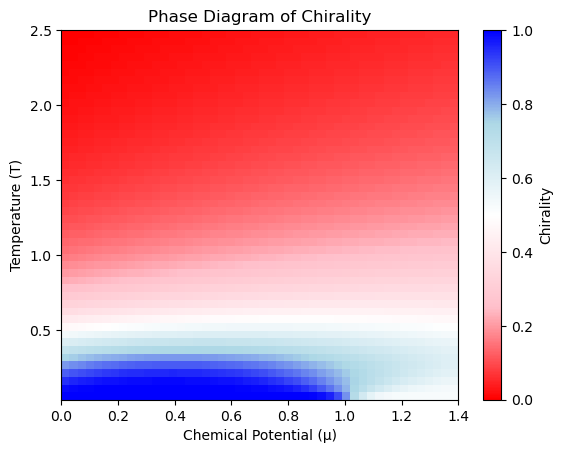

In [145]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as mcolors

# 假设mu_list和T_list已经定义，并且与chiral_mat的对应轴长度相同

# 将chiral_mat转换为numpy数组以便于处理
chiral_mat_N12_low_antisigma = np.transpose(np.abs(np.array(chiral_mat_N12_low)))

min_val = np.min(chiral_mat_N12_low_antisigma)
max_val = np.max(chiral_mat_N12_low_antisigma)
print(min_val, max_val)

chiral_mat_N12_low_antisigma = (chiral_mat_N12_low_antisigma - min_val)/(max_val - min_val)



# 创建自定义颜色图，0.5前后颜色不同且渐变
colors = ['red', 'pink', 'white', 'lightblue', 'blue']
cmap = mcolors.LinearSegmentedColormap.from_list('custom_cmap', colors)


# 创建图形和轴
fig, ax = plt.subplots()

# 创建热图
cax = ax.imshow(chiral_mat_N12_low_antisigma, aspect='auto', cmap=cmap, origin='lower', extent=[min(mu_list_low/g), max(mu_list_low/g), min(T_list_low/g), max(T_list_low/g)])

# 添加颜色条
cbar = fig.colorbar(cax)
cbar.set_label('Chirality')



# 设置轴标签
ax.set_xlabel('Chemical Potential (μ)')
ax.set_ylabel('Temperature (T)')

# 添加0.5等值线
#contour = ax.contour(chiral_mat, levels=[0.5], colors='black', origin='lower', extent=[min(mu_list/g), max(mu_list/g), min(T_list/g), max(T_list/g)])
#ax.clabel(contour, inline=1, fontsize=10)

# 设置标题
ax.set_title('Phase Diagram of Chirality')

# 显示图形
plt.show()

In [147]:
pred_diff_12 = np.load('C:\\Users\\robwa\\liif-main\\datasets\\Schwinger\\test\\N12\\N12w3_true_high_resolution_diff.npy')

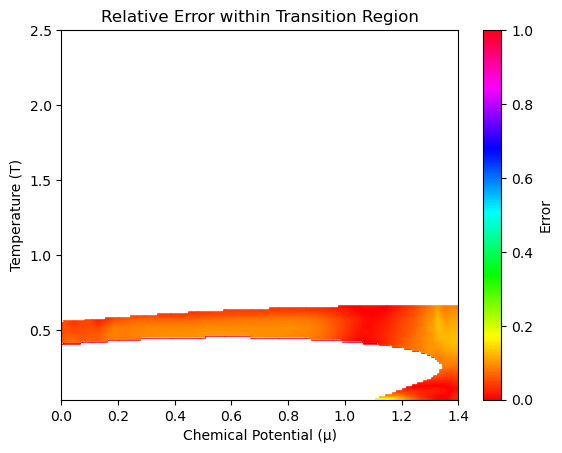

In [149]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as mcolors

# 假设mu_list和T_list已经定义，并且与chiral_mat的对应轴长度相同

pred_diff_12 = np.transpose(np.abs(np.array(pred_diff_12)))


for i in range(192):
    for j in range(192):
        if [i, j] not in transition_sites_12:
            pred_diff_12[i][j] = 10

white_spots = []
for i in range(192):
    for j in range(192):
        if pred_diff_12[i][j] == 10:
            white_spots.append([i, j])

# 创建自定义颜色图，0.5前后颜色不同且渐变
#colors = ['red', 'pink', 'white', 'lightblue', 'blue']
#cmap = mcolors.LinearSegmentedColormap.from_list('custom_cmap', colors)

norm = mcolors.Normalize(vmin=0, vmax=1)

# 创建图形和轴
fig, ax = plt.subplots()

# 创建热图

cax = ax.imshow(pred_diff_12, aspect='auto', cmap='hsv', origin='lower', extent=[min(mu_list/g), max(mu_list/g), min(T_list/g), max(T_list/g)], norm = norm)

# 添加颜色条
cbar = fig.colorbar(cax)
cbar.set_label('Error')

for coordinate in white_spots:
    x = coordinate[1]
    y = coordinate[0]
    x_value = x * (1.4/(192 - 1))
    y_value = (0.1/3) + y * ((2.5 - 0.1/3)/(192 - 1))
    plt.plot(x_value, y_value, 'w', marker = 's', markersize = 1.5)

# 设置轴标签
ax.set_xlabel('Chemical Potential (μ)')
ax.set_ylabel('Temperature (T)')

# 添加0.5等值线
#contour = ax.contour(chiral_mat, levels=[0.5], colors='black', origin='lower', extent=[min(mu_list/g), max(mu_list/g), min(T_list/g), max(T_list/g)])
#ax.clabel(contour, inline=1, fontsize=10)

# 设置标题
ax.set_title('Relative Error within Transition Region')

# 显示图形
plt.show()

In [151]:
interpo_diff_12 = np.load('C:\\Users\\robwa\\liif-main\\datasets\\Schwinger\\test\\N12\\N12w3_true_high_resolution_interpo.npy')

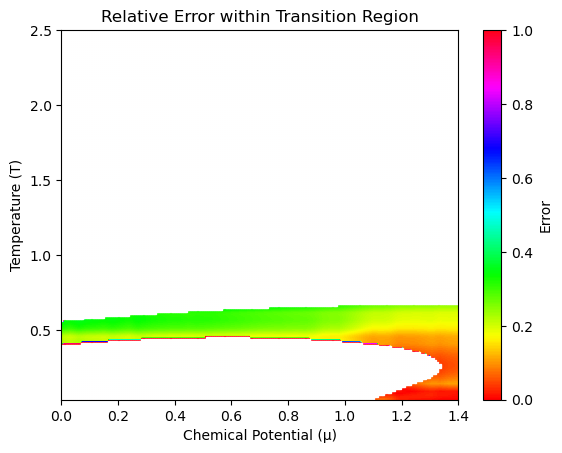

In [153]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as mcolors

# 假设mu_list和T_list已经定义，并且与chiral_mat的对应轴长度相同

interpo_diff_12 = np.transpose(np.abs(np.array(interpo_diff_12)))


for i in range(192):
    for j in range(192):
        if [i, j] not in transition_sites_12:
            interpo_diff_12[i][j] = 10

white_spots = []
for i in range(192):
    for j in range(192):
        if interpo_diff_12[i][j] == 10:
            white_spots.append([i, j])

# 创建自定义颜色图，0.5前后颜色不同且渐变
#colors = ['red', 'pink', 'white', 'lightblue', 'blue']
#cmap = mcolors.LinearSegmentedColormap.from_list('custom_cmap', colors)

norm = mcolors.Normalize(vmin=0, vmax=1)

# 创建图形和轴
fig, ax = plt.subplots()

# 创建热图

cax = ax.imshow(interpo_diff_12, aspect='auto', cmap='hsv', origin='lower', extent=[min(mu_list/g), max(mu_list/g), min(T_list/g), max(T_list/g)], norm = norm)

# 添加颜色条
cbar = fig.colorbar(cax)
cbar.set_label('Error')

for coordinate in white_spots:
    x = coordinate[1]
    y = coordinate[0]
    x_value = x * (1.4/(192 - 1))
    y_value = (0.1/3) + y * ((2.5 - 0.1/3)/(192 - 1))
    plt.plot(x_value, y_value, 'w', marker = 's', markersize = 1.5)

# 设置轴标签
ax.set_xlabel('Chemical Potential (μ)')
ax.set_ylabel('Temperature (T)')

# 添加0.5等值线
#contour = ax.contour(chiral_mat, levels=[0.5], colors='black', origin='lower', extent=[min(mu_list/g), max(mu_list/g), min(T_list/g), max(T_list/g)])
#ax.clabel(contour, inline=1, fontsize=10)

# 设置标题
ax.set_title('Relative Error within Transition Region')

# 显示图形
plt.show()